In [ ]:
# Наивная байесовская классификация
# Набор моделей, которые предлагают быстрые и простые алгоритмы классификации

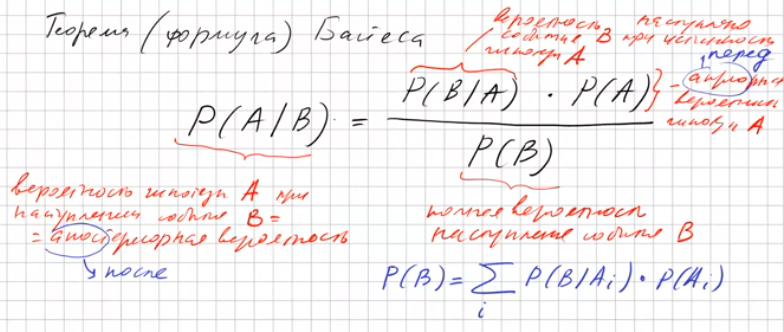

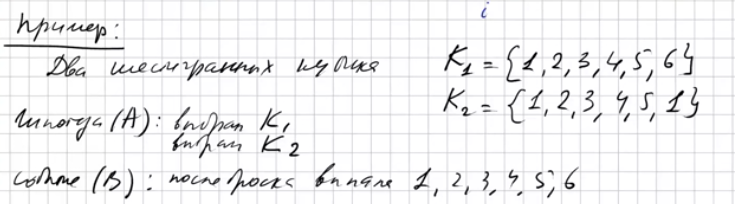

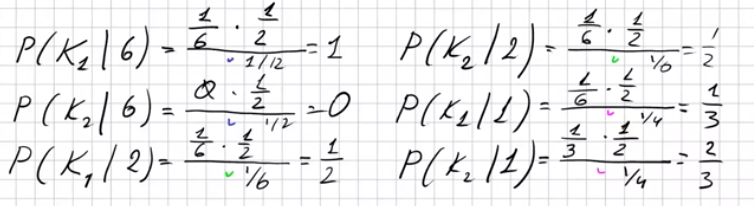

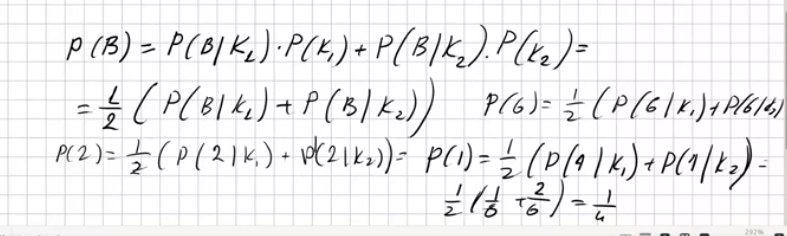

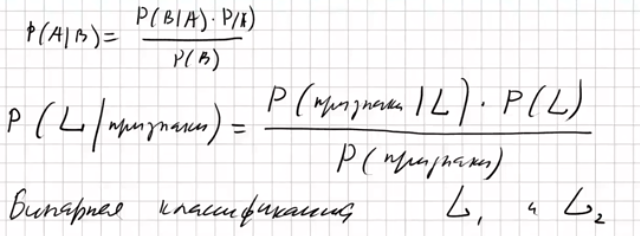

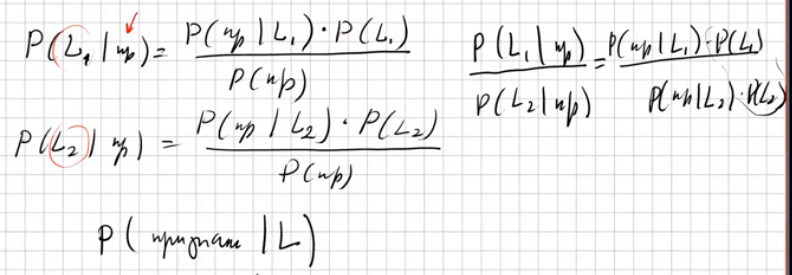

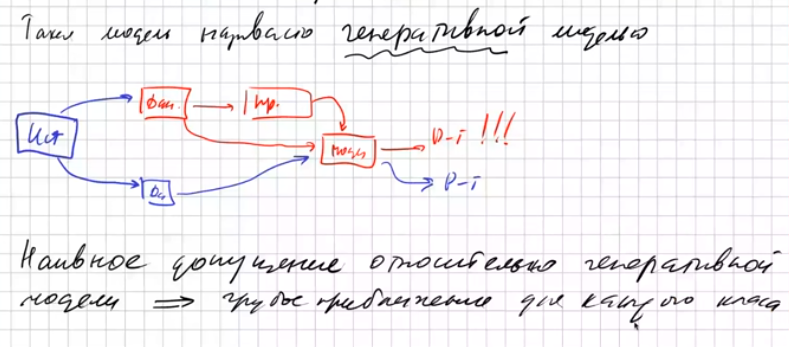

In [15]:
# Гауссовский наивный байесовский классификатор
# Допущение состоит в том, что 1 данные всех категорий взяты из простого нормального распределения 1
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.naive_bayes import GaussianNB

iris = sns.load_dataset("iris") 
print(iris.head())

   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa


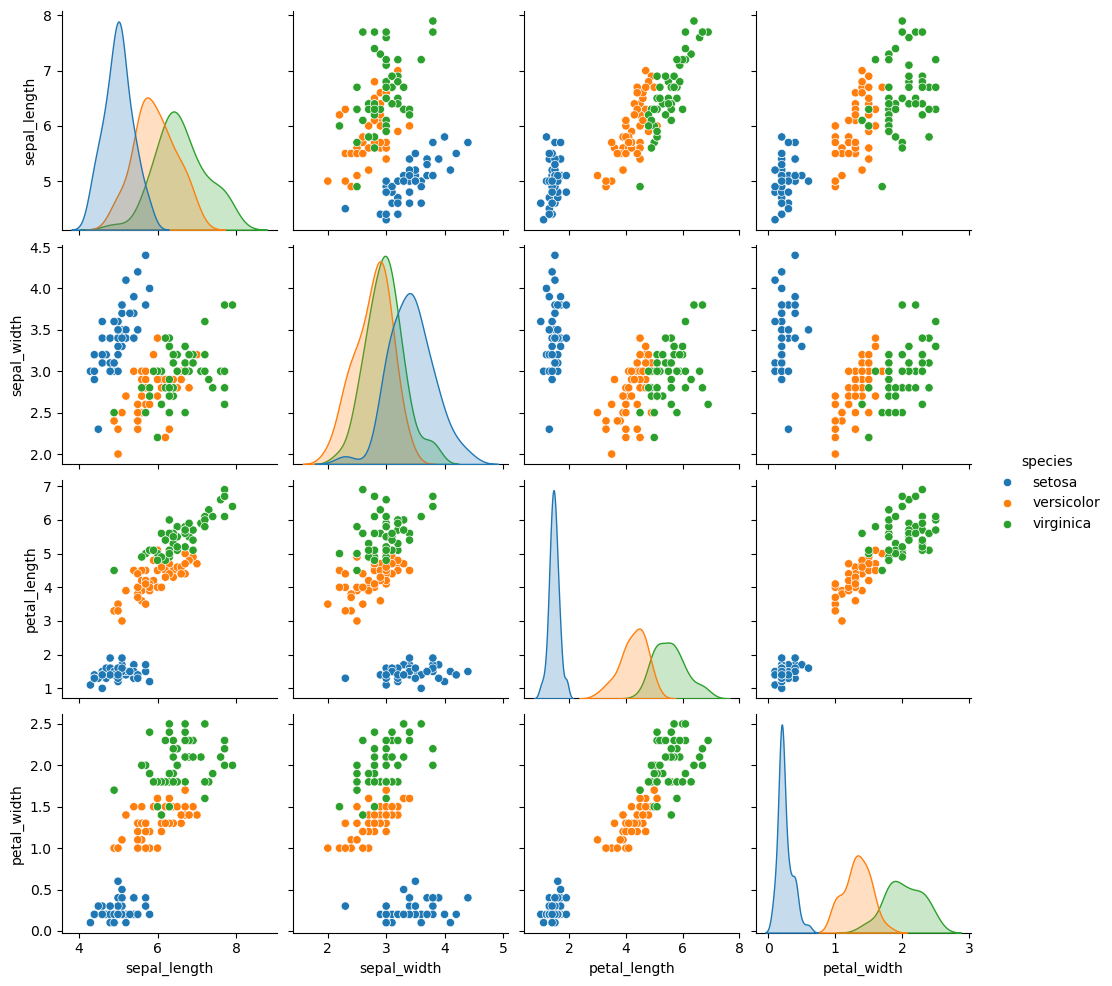

In [6]:
sns.pairplot(iris, hue="species")
plt.show()

In [9]:
data = iris[['sepal_length', 'petal_length', 'species']]
print(data.head())
print(data.shape)

   sepal_length  petal_length species
0           5.1           1.4  setosa
1           4.9           1.4  setosa
2           4.7           1.3  setosa
3           4.6           1.5  setosa
4           5.0           1.4  setosa
(150, 3)


In [13]:
#setosa versicolor
data_df = data[(data["species"] =="setosa") | (data["species"] == "versicolor")] 
print(data_df.shape) 

(100, 3)


[5.006 1.462]
[0.121764 0.029556]
[5.936 4.26 ]
[0.261104 0.2164  ]


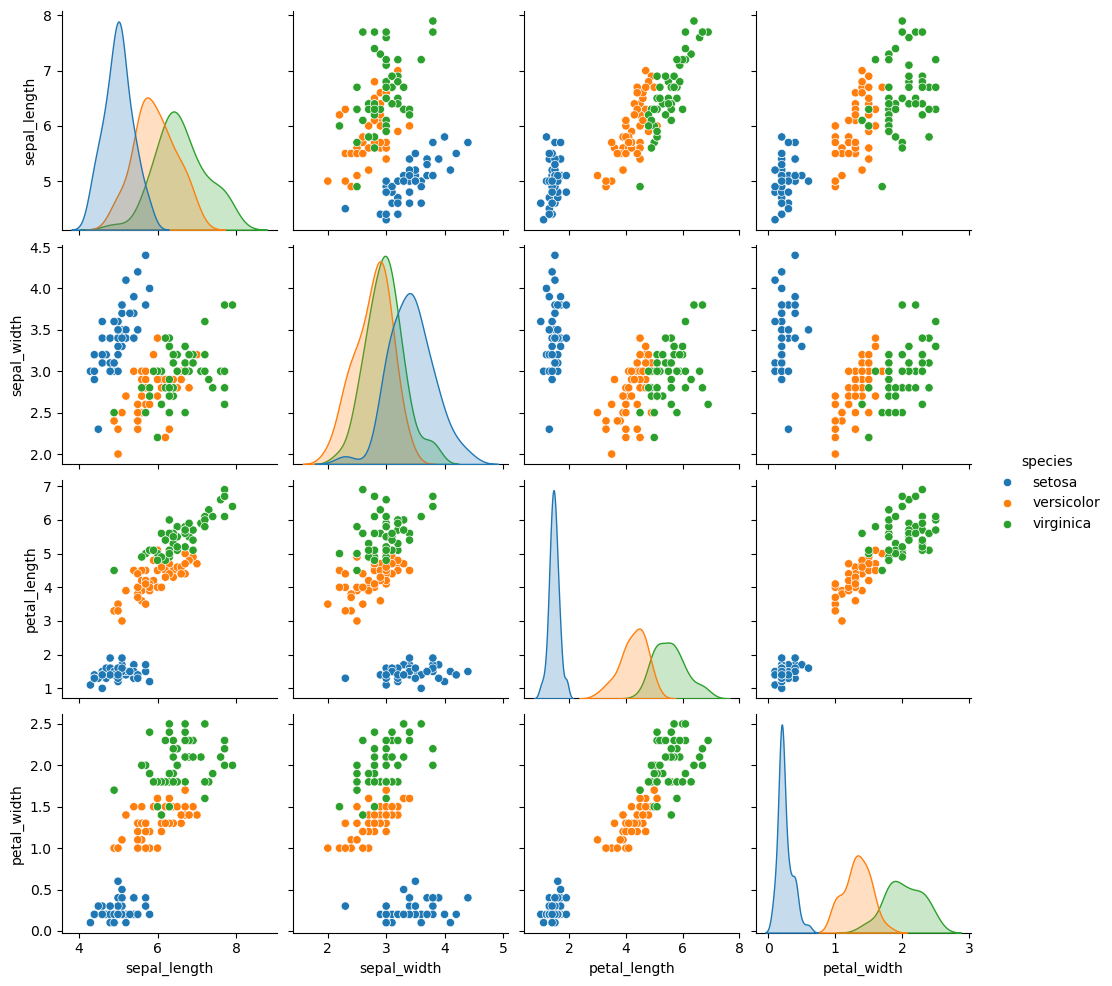

In [48]:
X = data_df[['sepal_length', 'petal_length']]
y = data_df['species']

model = GaussianNB()
model.fit(X, y)

print(model.theta_[0])
print(model.var_[0])
print(model.theta_[1])
print(model.var_[1])

theta0 = model.theta_[0]
var0 = model.var_[0]
theta1 = model.theta_[1]
var1 = model.var_[1]

sns.pairplot(iris, hue="species")
plt.show()

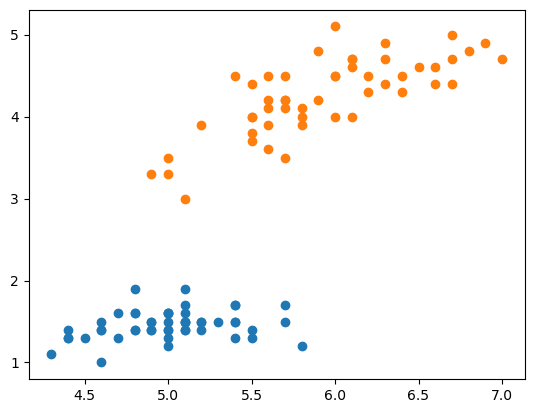

In [26]:
data_df_seposa = data_df[data_df["species"] == "setosa"] 
data_df_versicolor = data_df[data_df["species"] == "versicolor"]

plt.scatter(data_df_seposa["sepal_length"], data_df_seposa["petal_length"]) 
plt.scatter(data_df_versicolor["sepal_length"], data_df_versicolor["petal_length"])
plt.show()

In [42]:
x1_p = np.linspace (min(data_df["sepal_length"]), max(data_df["sepal_length"]), 100) 
x2_p = np.linspace (min(data_df["petal_length"]), max(data_df["petal_length"]), 100)
X1_p, X2_p = np.meshgrid(x1_p, x2_p)

X_p = pd.DataFrame(np.vstack([X1_p.ravel(), X2_p.ravel()]).T, columns=["sepal_length", "petal_length"])
print(X_p.head())

   sepal_length  petal_length
0      4.300000           1.0
1      4.327273           1.0
2      4.354545           1.0
3      4.381818           1.0
4      4.409091           1.0


In [53]:
z1 = (
    1
    / (1 * np.pi * (var0[0] * var0[1]) ** 0.5)
    * np.exp(
        -0.5
        * ((X1_p - theta0[0]) ** 2 / (var0[0]) + (X2_p - theta0[1]) ** 2 / (var0[1]))
    )
)

z2 = (
    1
    / (1 * np.pi * (var1[0] * var1[1]) ** 0.5)
    * np.exp(
        -0.5
        * ((X1_p - theta1[0]) ** 2 / (var1[0]) + (X2_p - theta1[1]) ** 2 / (var1[1]))
    )
)


In [43]:
y_p = model.predict(X_p)
X_p["species"] = y_p
X_p_setosa = X_p[X_p["species"] == "setosa"]
X_p_versicolor = X_p[X_p["species"] == "versicolor"]
print(X_p.head())

   sepal_length  petal_length species
0      4.300000           1.0  setosa
1      4.327273           1.0  setosa
2      4.354545           1.0  setosa
3      4.381818           1.0  setosa
4      4.409091           1.0  setosa


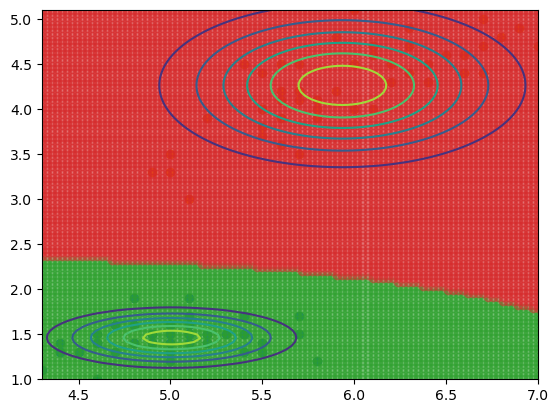

In [55]:
plt.scatter(data_df_seposa["sepal_length"], data_df_seposa["petal_length"]) 
plt.scatter(data_df_versicolor["sepal_length"], data_df_versicolor["petal_length"])
plt.scatter (X_p_setosa["sepal_length"], X_p_setosa["petal_length"], alpha=0.4)
plt.scatter (X_p_versicolor["sepal_length"], X_p_versicolor["petal_length"], alpha=0.4)
plt.contour(X1_p, X2_p, z1)
plt.contour(X1_p, X2_p, z2)

plt.show()

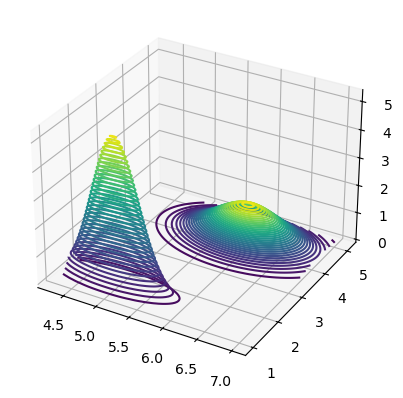

In [56]:
fig = plt.figure()
ax = plt.axes(projection='3d')
ax.contour3D(X1_p, X2_p, z1, 40)
ax.contour3D(X1_p, X2_p, z2, 40)

plt.show()